# Advanced Keras Techniques: Loops, Hyperparameter Tuning, and Model Optimization


## 3. Import the libraries

We import:

- `numpy` for numerical work
- `matplotlib` for visualization
- `tensorflow` and `keras` for modeling
- `keras_tuner` for hyperparameter tuning

A serious note: if `keras_tuner` is not installed in your environment, that is not a theory problem. That is just an environment problem. Install it and move on.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from tensorflow import keras
from tensorflow.keras import layers, regularizers

## 4. Load and inspect the dataset

We load MNIST and inspect the shapes.



In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Pixel range:", x_train.min(), x_train.max())

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Pixel range: 0 255


## 6. Preprocess the data

We normalize the pixel values and prepare the tensors for training.

We also create a validation split.


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Validation split
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train_small = x_train[:-10000]
y_train_small = y_train[:-10000]

print("Training shape:", x_train_small.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 28, 28, 1)
Validation shape: (10000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## 7. Build a `tf.data` input pipeline

Now we move beyond feeding raw NumPy arrays directly.

A `tf.data.Dataset` pipeline gives better control and better scaling.

We use it to:

- shuffle training data
- batch the data
- prefetch batches for efficiency

This is one of the first practical upgrades from beginner Keras to stronger Keras workflows.


In [4]:
batch_size = 128

train_ds = tf.data.Dataset.from_tensor_slices((x_train_small, y_train_small))
train_ds = train_ds.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

## 8. Define a custom layer

Keras allows you to define your own layers by subclassing `layers.Layer`.

This matters because in real projects, you will not always use only built-in layers.

Here we define a small custom layer that applies a dense transformation, batch normalization, activation, and dropout in one reusable block.


In [5]:
class DenseBlock(layers.Layer):
    def __init__(self, units, dropout_rate=0.3):
        super().__init__()
        self.dense = layers.Dense(units)
        self.bn = layers.BatchNormalization()
        self.activation = layers.ReLU()
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        x = self.dense(inputs)
        x = self.bn(x, training=training)
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return x

## 9. Define a subclassed model

Instead of using only `Sequential` or even the Functional API, we now define a model by subclassing `keras.Model`.

This gives you more flexibility.

It is especially useful when:

- the forward pass is not simple
- you want custom behavior
- you need more architectural control
- you want to override training or testing logic later



In [6]:
class AdvancedClassifier(keras.Model):
    def __init__(self, num_classes=10):
        super().__init__()
        self.flatten = layers.Flatten()
        self.block1 = DenseBlock(256, dropout_rate=0.3)
        self.block2 = DenseBlock(128, dropout_rate=0.3)
        self.output_layer = layers.Dense(num_classes, activation="softmax")

    def call(self, inputs, training=False):
        x = self.flatten(inputs)
        x = self.block1(x, training=training)
        x = self.block2(x, training=training)
        return self.output_layer(x)

## 10. Instantiate and inspect the model

We now create the subclassed model and inspect its output shapes.

With subclassed models, a summary is only available after the model has been built or called once.


In [7]:
model = AdvancedClassifier()

# Build the model by calling it once
dummy_input = tf.random.normal((1, 28, 28, 1))
_ = model(dummy_input)

model.summary()

 Non-trainable params: 768 (3.00 KB)

## 11. Compile and train with the standard `.fit()` API first

Before writing a custom loop, we still train the model once with normal Keras `.fit()`.

We also add callbacks such as:

- EarlyStopping
- ModelCheckpoint
- ReduceLROnPlateau


In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_standard_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9792 - loss: 0.0638 - val_accuracy: 0.9798 - val_loss: 0.0713 - learning_rate: 0.0010


## 12. Plot learning curves

After training, inspect the history.

Plotting loss and accuracy helps you see:

- whether learning is happening
- whether overfitting is starting
- whether validation performance is improving or stalling


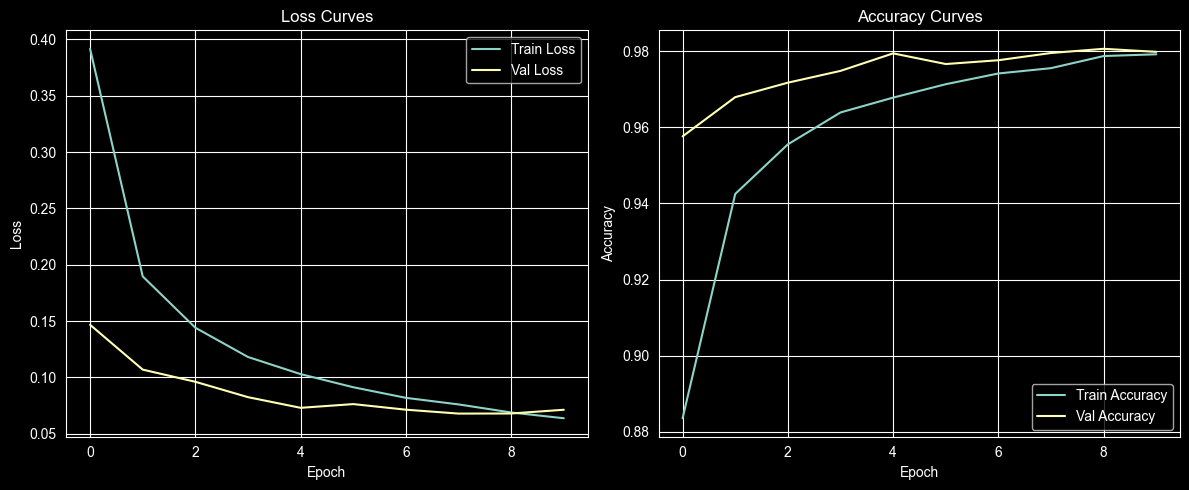

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Evaluate the trained model

We evaluate on the test set.

This gives a clean baseline before we move into a custom training loop and tuning.


In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.0656391829252243
Test accuracy: 0.9793999791145325


## 14. Why custom training loops matter

At some point, `.fit()` is not enough.

You may need:

- multiple optimizers
- unusual loss structures
- gradient accumulation
- manual logging
- reinforcement learning style updates
- GAN-style alternating updates
- more control over what happens per batch


## 15. Define a second model for custom-loop training

To keep the comparison clean, we define a fresh model instance for custom-loop training.

We also define:

- loss function
- optimizer
- training metric objects
- validation metric objects

This shows how Keras metrics can be managed manually in a loop.


In [13]:
custom_model = AdvancedClassifier()
_ = custom_model(tf.random.normal((1, 28, 28, 1)))

loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

train_loss_metric = keras.metrics.Mean()
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

val_loss_metric = keras.metrics.Mean()
val_acc_metric = keras.metrics.SparseCategoricalAccuracy()

## 16. Define `train_step` and `test_step`

We now write the training logic ourselves.

This includes:

- forward pass
- loss computation
- gradient computation
- optimizer update
- metric updates

This is one of the most important sections in the notebook.

If you really want to understand Keras deeply, you must be able to explain what happens inside one training step.


In [14]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = custom_model(images, training=True)
        loss = loss_fn(labels, predictions)

    gradients = tape.gradient(loss, custom_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, custom_model.trainable_variables))

    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(labels, predictions)


@tf.function
def test_step(images, labels):
    predictions = custom_model(images, training=False)
    loss = loss_fn(labels, predictions)

    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(labels, predictions)

## 17. Run a custom training loop

Now we manually loop over epochs and batches.

This makes the training process fully explicit.

- layers work the same
- losses work the same
- optimizers work the same
- metrics work the same


In [15]:
epochs = 5

custom_train_losses = []
custom_val_losses = []
custom_train_accs = []
custom_val_accs = []

for epoch in range(epochs):
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    for images, labels in train_ds:
        train_step(images, labels)

    for images, labels in val_ds:
        test_step(images, labels)

    train_loss = train_loss_metric.result().numpy()
    train_acc = train_acc_metric.result().numpy()
    val_loss = val_loss_metric.result().numpy()
    val_acc = val_acc_metric.result().numpy()

    custom_train_losses.append(train_loss)
    custom_val_losses.append(val_loss)
    custom_train_accs.append(train_acc)
    custom_val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
    )

Epoch 5/5 - train_loss: 0.1034 - train_acc: 0.9687 - val_loss: 0.0755 - val_acc: 0.9776


## 18. Compare standard training and custom-loop training

Now compare the two approaches.


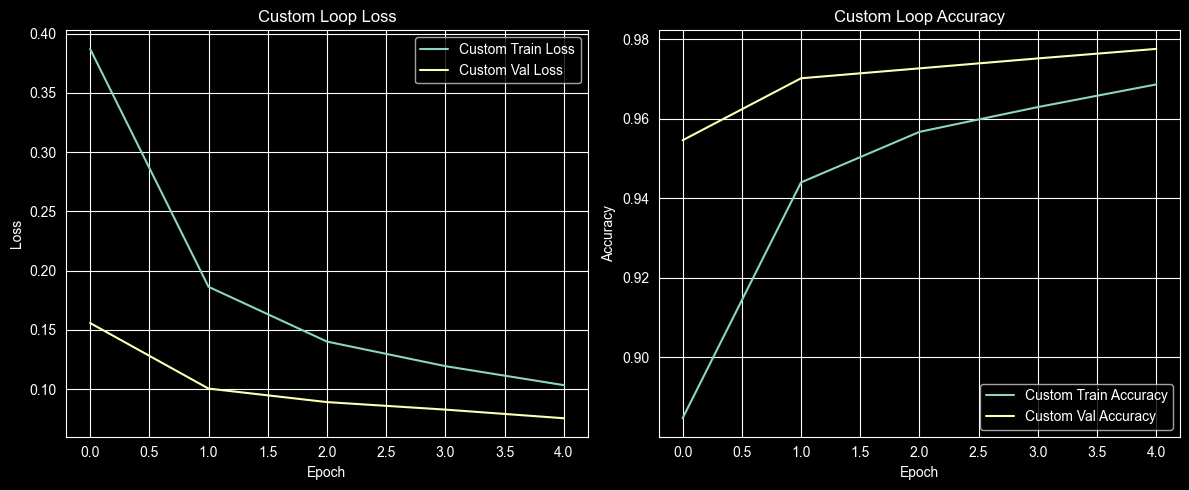

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(custom_train_losses, label="Custom Train Loss")
plt.plot(custom_val_losses, label="Custom Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom Loop Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(custom_train_accs, label="Custom Train Accuracy")
plt.plot(custom_val_accs, label="Custom Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom Loop Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 19. Introduce hyperparameter tuning with Keras Tuner

Now we move to hyperparameter tuning.

The point of tuning is not random experimentation. The point is structured search over model and training choices.

Typical tunable values include:

- number of units
- dropout rate
- learning rate
- number of layers
- activation choices
- regularization strength



In [22]:
def build_tunable_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Flatten())

    units_1 = hp.Int("units_1", min_value=128, max_value=512, step=64)
    dropout_1 = hp.Float("dropout_1", min_value=0.2, max_value=0.5, step=0.1)

    model.add(layers.Dense(units_1, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_1))

    units_2 = hp.Int("units_2", min_value=64, max_value=256, step=64)
    dropout_2 = hp.Float("dropout_2", min_value=0.2, max_value=0.5, step=0.1)

    model.add(layers.Dense(units_2, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_2))

    model.add(layers.Dense(10, activation="softmax"))

    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 5e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 20. Define a model-building function for Keras Tuner

Keras Tuner needs a function that builds and compiles a model based on sampled hyperparameters.



In [23]:
tuner = kt.RandomSearch(
    build_tunable_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="keras_tuner_dir",
    project_name="advanced_keras_mnist"
)

Reloading Tuner from keras_tuner_dir\advanced_keras_mnist\tuner0.json


## 21. Run hyperparameter search

We run a tuner search on the validation split.



In [25]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Trial 5 Complete [00h 00m 14s]
val_accuracy: 0.974399983882904

Best val_accuracy So Far: 0.974399983882904
Total elapsed time: 00h 01m 05s


## 22. Inspect the best hyperparameters

After search, inspect what the tuner found.



In [26]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best units_1:", best_hp.get("units_1"))
print("Best dropout_1:", best_hp.get("dropout_1"))
print("Best units_2:", best_hp.get("units_2"))
print("Best dropout_2:", best_hp.get("dropout_2"))
print("Best learning_rate:", best_hp.get("learning_rate"))

Best units_1: 512
Best dropout_1: 0.4
Best units_2: 128
Best dropout_2: 0.2
Best learning_rate: 0.01


## 23. Retrain the best tuned model

Once we get the best hyperparameters, we rebuild the best model and train it again properly.


In [27]:
best_model = tuner.hypermodel.build(best_hp)

best_history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9760 - loss: 0.0768 - val_accuracy: 0.9787 - val_loss: 0.0730


## 25. Add regularization to a tuned architecture

A model can fit training data well and still generalize badly.

Regularization helps push back against that.



In [28]:
regularized_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_model.summary()

 Non-trainable params: 768 (3.00 KB)

In [29]:
regularized_history = regularized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9674 - loss: 0.1494 - val_accuracy: 0.9784 - val_loss: 0.1220


In [30]:
best_model.save("best_tuned_model.keras")
print("Saved model file exists:", os.path.exists("best_tuned_model.keras"))

Saved model file exists: True


## 27. Convert the model to TensorFlow Lite

TensorFlow Lite conversion is relevant when deploying models to lightweight environments such as:

- mobile devices
- embedded systems
- edge devices


In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

with open("best_tuned_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved.")

TFLite model saved.


## 28. Compare model file sizes

It is useful to inspect how large your saved model artifacts are.


In [32]:
keras_size = os.path.getsize("best_tuned_model.keras") / 1024
tflite_size = os.path.getsize("best_tuned_model.tflite") / 1024

print(f"Keras model size: {keras_size:.2f} KB")
print(f"TFLite model size: {tflite_size:.2f} KB")

Keras model size: 5557.52 KB
TFLite model size: 1835.33 KB


## 29. Final evaluation and prediction inspection

We end by making predictions on a few test samples and checking whether the model behaves sensibly.




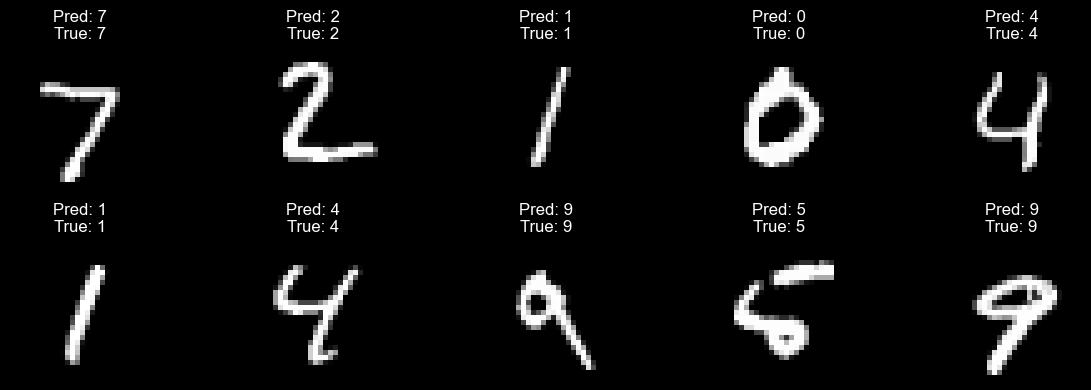

In [33]:
predictions = best_model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()